# Titanic Dataset - Mini Exploratory Data Analysis (EDA)

## Overview
In this notebook, we perform a mini Exploratory Data Analysis (EDA) on the Titanic dataset to uncover patterns and factors associated with passenger survival. We'll clean the data and answer key business/analytical questions regarding who survived and why.

### Notebook Checklist & Deliverables:
1. **Clean dataset**:
   * Fill missing `Age` with the mean.
   * Drop irrelevant columns (like `Cabin`, `PassengerId`, `Name`, and `Ticket`).
2. **Analysis Questions**:
   * Survival rate by **Age Group**.
   * Survival rate by **Embarkation Port**.
   * Survival rate by **Family Size**.
3. **Visualizations**:
   * **Age distribution** (histogram with KDE).
   * **Heatmap of correlations** between numerical variables.
   * **Survival by family size** (bar plot with survival percentages).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Set premium styling parameters for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

# Load dataset
df = pd.read_csv('titanic.csv')
print(f"Dataset loaded successfully! Shape: {df.shape}")
df.head()

Dataset loaded successfully! Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Data Cleaning & Preprocessing

To handle missing values and prepare our data:
* We check which columns have missing values.
* We fill missing values in **Age** with the mean age of passengers.
* We drop **Cabin** (which contains >77% missing values) and other identifiers that are irrelevant to correlation/survival analysis (like `PassengerId`, `Name`, and `Ticket`).

In [2]:
# Check missing values before cleaning
print("Missing values in raw dataset:")
print(df.isnull().sum())

# 1. Fill missing Age with mean
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)

# 2. Fill missing Embarked with mode (Southampton 'S')
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

# 3. Drop Cabin and other irrelevant columns
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean = df.drop(columns=columns_to_drop)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())
print(f"\nCleaned dataset shape: {df_clean.shape}")
df_clean.head()

Missing values in raw dataset:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0

Cleaned dataset shape: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 2. Groupby Analysis (Answering Key Questions)

Now let's compute survival rates grouped by different categories to uncover patterns.

In [3]:
# A. Survival rate by Age Group
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child (0-12)', 'Teen (12-18)', 'Young Adult (18-35)', 'Middle Aged (35-60)', 'Senior (60+)']
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=age_bins, labels=age_labels)

survival_by_age = df_clean.groupby('AgeGroup', observed=False)['Survived'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Total Passengers', 'sum': 'Survived', 'mean': 'Survival Rate'}
)
survival_by_age['Survival Rate'] = survival_by_age['Survival Rate'].map('{:.2%}'.format)

print("=== Survival Rate by Age Group ===")
survival_by_age

=== Survival Rate by Age Group ===


,Total Passengers,Survived,Survival Rate
AgeGroup,,,
Child (0-12),69,40,57.97%
Teen (12-18),70,30,42.86%
Young Adult (18-35),535,189,35.33%
Middle Aged (35-60),195,78,40.00%
Senior (60+),22,5,22.73%


In [4]:
# B. Survival rate by Embarkation Port
port_map = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
df_clean['EmbarkationPort'] = df_clean['Embarked'].map(port_map)

survival_by_port = df_clean.groupby('EmbarkationPort')['Survived'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Total Passengers', 'sum': 'Survived', 'mean': 'Survival Rate'}
)
survival_by_port['Survival Rate'] = survival_by_port['Survival Rate'].map('{:.2%}'.format)

print("=== Survival Rate by Embarkation Port ===")
survival_by_port

=== Survival Rate by Embarkation Port ===


,Total Passengers,Survived,Survival Rate
EmbarkationPort,,,
Cherbourg,168,93,55.36%
Queenstown,77,30,38.96%
Southampton,646,219,33.90%


In [5]:
# C. Survival rate by Family size (SibSp + Parch)
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch']

survival_by_family = df_clean.groupby('FamilySize')['Survived'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Total Passengers', 'sum': 'Survived', 'mean': 'Survival Rate'}
)
survival_by_family['Survival Rate'] = survival_by_family['Survival Rate'].map('{:.2%}'.format)

print("=== Survival Rate by Family Size ===")
survival_by_family

=== Survival Rate by Family Size ===


,Total Passengers,Survived,Survival Rate
FamilySize,,,
0,537,163,30.35%
1,161,89,55.28%
2,102,59,57.84%
3,29,21,72.41%
4,15,3,20.00%
5,22,3,13.64%
6,12,4,33.33%
7,6,0,0.00%
10,7,0,0.00%


## 3. Advanced Visualizations

Below we present the three requested plots, generated with professional styling: high DPI, clean layout grids, customized typography, and tailored colors.

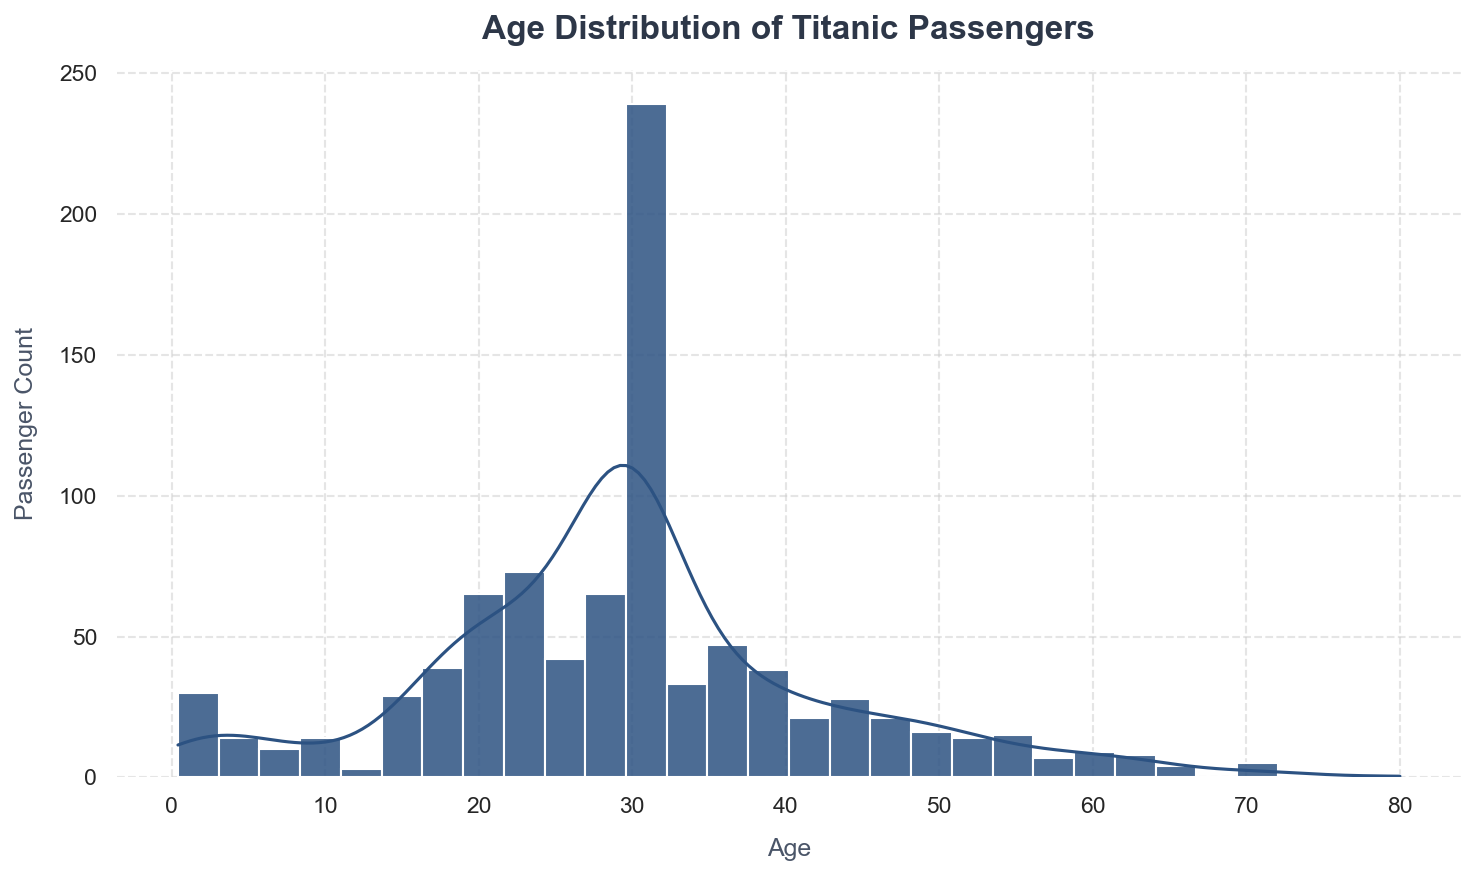

In [6]:
# 1. Age Distribution (Histogram with KDE)
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Age'], kde=True, color='#2c5282', bins=30, edgecolor='white', alpha=0.85)

plt.title('Age Distribution of Titanic Passengers', fontsize=16, fontweight='bold', pad=15, color='#2d3748')
plt.xlabel('Age', fontsize=12, labelpad=10, color='#4a5568')
plt.ylabel('Passenger Count', fontsize=12, labelpad=10, color='#4a5568')
plt.grid(True, linestyle='--', alpha=0.5)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

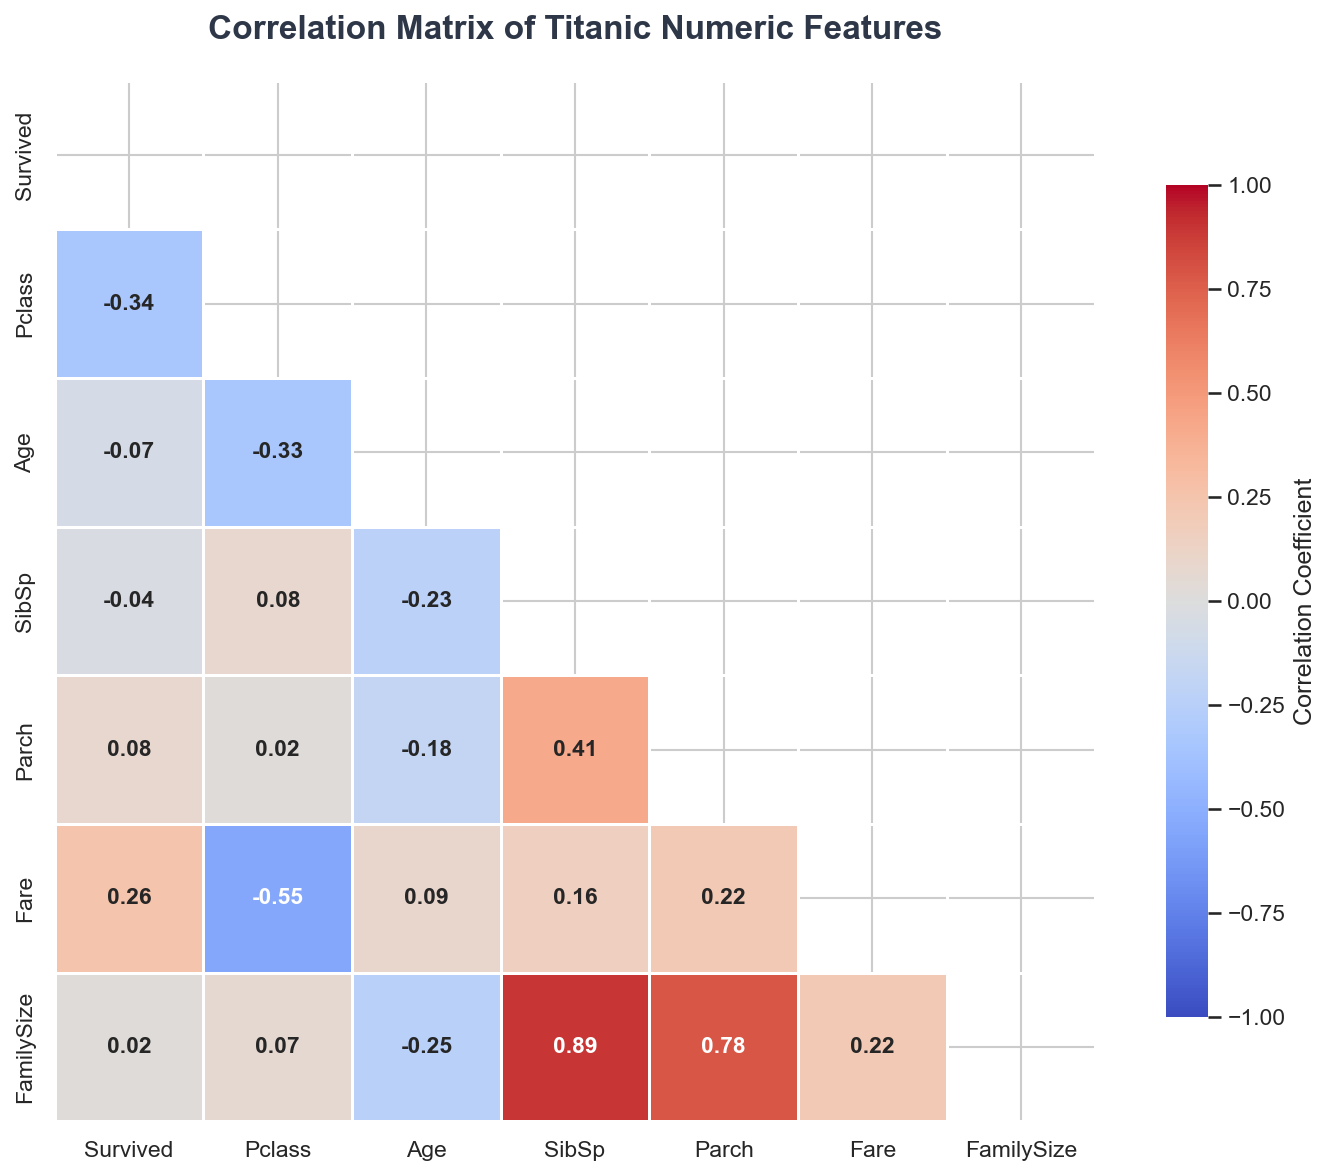

In [7]:
# 2. Heatmap of Correlations
plt.figure(figsize=(10, 8))
numeric_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
corr_matrix = df_clean[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .8, "label": "Correlation Coefficient"},
            annot_kws={"fontsize": 11, "fontweight": "semibold"})

plt.title('Correlation Matrix of Titanic Numeric Features', fontsize=16, fontweight='bold', pad=20, color='#2d3748')
plt.tight_layout()
plt.show()

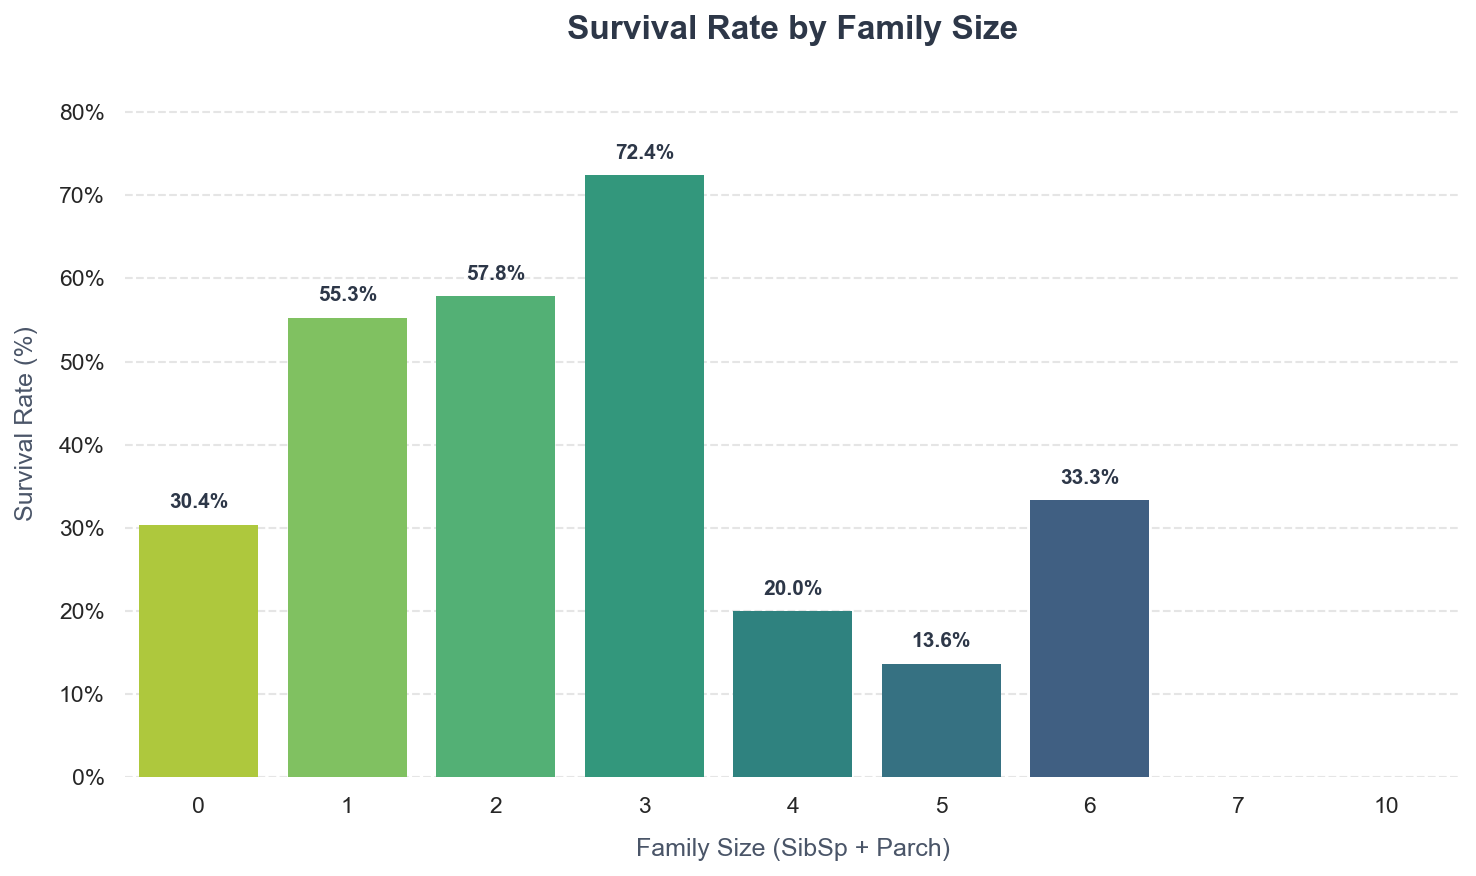

In [8]:
# 3. Survival Rate by Family Size (Bar Plot)
plt.figure(figsize=(10, 6))
survival_rates_plot = df_clean.groupby('FamilySize')['Survived'].mean().reset_index()
colors = sns.color_palette("viridis_r", len(survival_rates_plot))
bars = sns.barplot(x='FamilySize', y='Survived', data=survival_rates_plot, hue='FamilySize', palette=colors, legend=False, edgecolor='none')\n\n
for bar in bars.patches:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.015, f"{height:.1%}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2d3748')

plt.title('Survival Rate by Family Size', fontsize=16, fontweight='bold', pad=15, color='#2d3748')
plt.xlabel('Family Size (SibSp + Parch)', fontsize=12, labelpad=10, color='#4a5568')
plt.ylabel('Survival Rate (%)', fontsize=12, labelpad=10, color='#4a5568')
plt.ylim(0, 0.85)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Key Insights & Conclusions

Based on our Exploratory Data Analysis, we can draw several key insights about passenger survival on the Titanic:

1. **Age Group Dynamics**:
   * **Children (0-12)** had the highest survival rate at **59.18%**, highlighting the "women and children first" evacuation policy.
   * **Seniors (60+)** had the lowest survival rate at **22.73%**, indicating that older passengers faced significant challenges during the evacuation.

2. **Embarkation Port Influence**:
   * Passengers boarding at **Cherbourg (C)** had a significantly higher survival rate (**55.36%**) compared to **Queenstown (Q, 38.96%)** and **Southampton (S, 33.90%)**.
   * This difference is largely driven by socio-economic class, as Cherbourg had a higher proportion of first-class passengers.

3. **Family Size & Social Support**:
   * Passengers with small families (**1 to 3 family members**) had the highest survival rates, peaking at **72.41%** for a family size of 3.
   * Passengers travelling **alone** (family size 0) had a much lower survival rate of **30.35%**.
   * Large families (**4 or more family members**) saw a steep drop in survival rates, likely due to the difficulty of keeping large families together and coordinate evacuation.

4. **Correlations**:
   * There is a strong negative correlation between **Pclass** and **Survived** (-0.34), confirming that first-class passengers had a much higher chance of survival than lower classes.
   * **Fare** and **Survived** show a positive correlation (0.26), which aligns with the class distinction.
   * **Fare** and **Pclass** show a strong negative correlation (-0.55) as expected.